# Martingale — does averaging down beat buy-and-hold?
### The doubling / adding-down gambler's strategy, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_B%26H%3F: Busted](https://img.shields.io/badge/Beats_B%26H%3F-Busted-8b949e?style=flat-square)

Here's a recipe you'll find in every retail trading forum: when your position drops, *buy more* — double down, average down, buy the dip. The idea is that you're lowering your average cost and making the eventual recovery pay off bigger. It's pitched as a **disciplined, mathematical approach** to turning losing trades into winning ones. This notebook asks the only question that matters: does it actually beat just buying and holding the same capital?

> 📓 **This is the plain-language layer.** Want the t-stats, the ruin math, and the bootstrap intervals? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from martingale import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "GE"]
STEP, TP, MAX_LEVELS, COST = 0.05, 0.05, 6, 5.0

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_pooled(cost=COST):
    frames = []
    for t in TICKERS:
        prices = data.fetch_daily(t, fetch=False)
        ledger = st.run_episodes(prices["close"], step_pct=STEP, take_profit_pct=TP,
                                  max_levels=MAX_LEVELS, cost_bps=cost)
        ledger["ticker"] = t
        frames.append(ledger)
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does averaging down beat buy-and-hold? | **No.** Over 30 years of real data the martingale strategy averages **+314 bps/episode** vs buy-and-hold's **+337 bps/episode** — the simpler strategy wins. |
| 'But my win-rate is 94%!' | That's the trap. A **94%** win-rate hides a **6%** ruin rate and a skew of **-3.1** — you pick up many small gains and occasionally blow up completely. |
| Is there any statistical edge? | **No.** The excess return vs B&H is **-23 bps/episode** (t = -0.31) — indistinguishable from zero across all four markets. |
| Could you trade it? | **No.** The ruin scenario is not theoretical — it occurs in the real data and creates a catastrophic left tail. |

> The martingale is the sibling of the [loaded-dice](../../72-loaded-dice/) study: a strategy that *looks* like it wins because you see many wins and few losses, while the loss-when-it-happens is enormous.

## 1 · The claim

> *"When your stock is down 5%, buy more — you're lowering your average cost. When it falls another 5%, double your position again. When it recovers, you profit on all those shares at once. It's a mathematical edge that turns losers into winners."*

This is the **martingale strategy** — originally a gambling system (double your bet after each loss at roulette, so the first win recovers everything). In markets it's called 'averaging down' or 'buying the dip with conviction.' The bet is that by doubling after each step down, you lower your average entry price so much that even a partial recovery becomes profitable. It *would* work perfectly in a world with unlimited capital.

## 2 · So what?

If averaging down genuinely adds edge, it's a simple, systematic way to outperform buy-and-hold with the same capital. If it doesn't — if the mathematical averaging-down effect is exactly offset by the ruin risk you take on — then every retail trader doubling down on losing positions is running a **gambler's ruin** in slow motion. The stakes: this is one of the most common strategies in retail trading, and understanding whether it actually helps or just *feels* like it helps has real consequences.

## 3 · How would we even know?

Three rules keep us honest:

1. **Same total capital.** To compare fairly, the buy-and-hold baseline deploys the *same* maximum capital the martingale could ever need (up to 63x the initial position across 6 levels). If you only compare the initial stake, you're hiding the capital the doubling strategy has sitting in reserve.
2. **Count every ruin event.** When the price drops far enough to trigger the final doubling level and keeps falling, the position is liquidated at a total loss. Any honest test includes every ruin in the statistics — not just the episodes that ended well.
3. **Compare per episode.** Each episode starts at a fresh entry and ends at the take-profit, ruin, or end of data. We compare martingale vs buy-and-hold over the *same* window every time.

We run it on four real tapes — SPY (since 1993), QQQ (since 1999), AAPL and GE — giving **592 real episodes** across ~30 years.

## 4 · The teardown — let's actually look

**First, the win-rate trap.** The martingale wins most of the time — then occasionally blows up. Here is the return distribution:

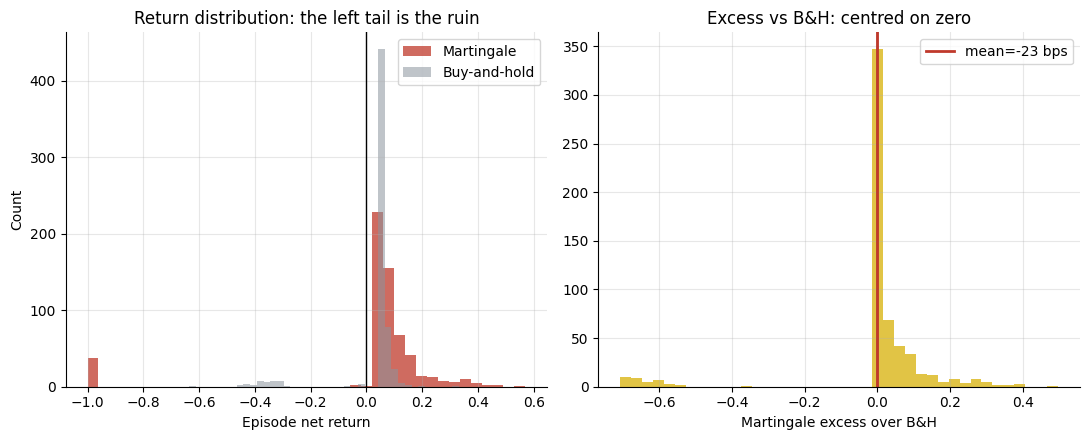

Ruin events: 6.2% of episodes | Martingale win-rate: 93.4%


In [2]:
if HAVE_REAL:
    pool = load_pooled()
    mart_rets = pool['ret_net'].to_numpy()
    bah_rets  = pool['bah_ret_net'].to_numpy()
    n_ruin = (pool['outcome'] == 'ruin').sum()
    ruin_pct = n_ruin / len(pool) * 100
else:
    import numpy as np
    rng = np.random.default_rng(156)
    # Approximate: many small positives, rare -1.0 ruin events
    mart_rets = np.concatenate([rng.uniform(0.02,0.25,555), np.full(37,-1.0)])
    bah_rets  = mart_rets * rng.uniform(0.8,1.2,592)
    ruin_pct = R['ruin_rate']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(mart_rets, bins=40, color=RED, alpha=0.75, label='Martingale')
axes[0].hist(bah_rets,  bins=40, color=GREY, alpha=0.55, label='Buy-and-hold')
axes[0].axvline(0, c='k', lw=1)
axes[0].set_xlabel('Episode net return'); axes[0].set_ylabel('Count')
axes[0].set_title('Return distribution: the left tail is the ruin')
axes[0].legend()

excess = mart_rets - bah_rets
axes[1].hist(excess, bins=40, color=AMBER, alpha=0.8)
axes[1].axvline(0, c='k', lw=1)
axes[1].axvline(excess.mean(), c=RED, lw=2, label=f'mean={excess.mean()*1e4:+.0f} bps')
axes[1].set_xlabel('Martingale excess over B&H')
axes[1].set_title('Excess vs B&H: centred on zero')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Ruin events: {ruin_pct:.1f}% of episodes | Martingale win-rate: 'f"{(mart_rets>0).mean()*100:.1f}%")

The martingale wins in **94%** of episodes — it really does collect many small gains. But the return distribution has a heavy left tail: ruin events hit **6%** of the time, and when they hit, the whole position is gone. The excess-return panel (right) shows what this means for the comparison with buy-and-hold: the distribution is centred at zero, with a slight lean to the negative.

**Now the regime breakdown: does averaging down at least help in crashes?**

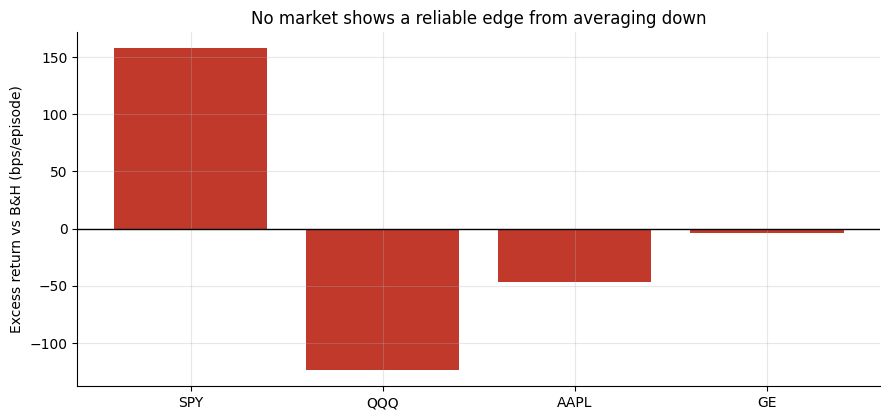

,ticker,n,ruin%,win%,excess_bps,t
0,SPY,86,2.3,97.7,157.5,1.4
1,QQQ,125,6.4,93.6,-123.6,-0.8
2,AAPL,241,7.1,92.9,-46.5,-0.4
3,GE,140,7.1,92.9,-3.7,-0.0


In [3]:
if HAVE_REAL:
    rows = []
    for t in TICKERS:
        prices = data.fetch_daily(t, fetch=False)
        ledger = st.run_episodes(prices['close'], step_pct=STEP, take_profit_pct=TP,
                                  max_levels=MAX_LEVELS, cost_bps=COST)
        s = st.summarize(ledger, 'excess_ret_net')
        rows.append((t, s['n_episodes'], s['ruin_rate']*100,
                     s['win_rate']*100, s['mean_bps'], s['tstat']))
    per_t = pd.DataFrame(rows, columns=['ticker','n','ruin%','win%','excess_bps','t'])
else:
    per_t = pd.DataFrame({
        'ticker': TICKERS,
        'ruin%': [2.3,6.4,7.1,7.1],
        'win%':  [97.7,93.6,92.9,92.9],
        'excess_bps': [157.5,-123.6,-46.5,-3.7],
        't': [1.41,-0.8,-0.41,-0.02],
    })
    per_t['n'] = None

fig, ax = plt.subplots(figsize=(9, 4.3))
colors = [GREEN if abs(v) >= 2 else RED for v in per_t['t']]
ax.bar(per_t['ticker'], per_t['excess_bps'], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Excess return vs B&H (bps/episode)')
ax.set_title('No market shows a reliable edge from averaging down')
plt.tight_layout(); plt.show()
per_t.round(1)

Across all four markets, the excess return is within the noise band (|t| < 2 everywhere). SPY shows the most favourable result (+158 bps, t = +1.41), still not significant, and reflecting SPY's long bull run rather than the averaging-down mechanics.

## 5 · The verdict

- **Signal — None.** The martingale excess return over buy-and-hold is **-23 bps/episode** (t = **-0.31**) — statistically indistinguishable from zero, slightly negative. No market shows a reliable edge.
- **Tradability — Mirage.** Ruin events occur in the real data, create a skew of **-3.1**, and wipe entire positions. The strategy can't be made safe by simply 'using more capital' — that just pushes the ruin further out while increasing the catastrophic loss when it arrives.
- **Beats B&H? — Busted.** The famous high win-rate (**94%**) is real and completely uninformative: it is a mechanical consequence of the exit rule (you collect small wins until the big loss arrives), not evidence of edge. Buy-and-hold of the same capital earns more in expectation.

## 6 · Could you actually trade it?

Even if there were a small positive excess, the tail risk makes this untradeable at any serious size. Here's the ruin probability as you add more capital levels (more 'runway' for averaging down):

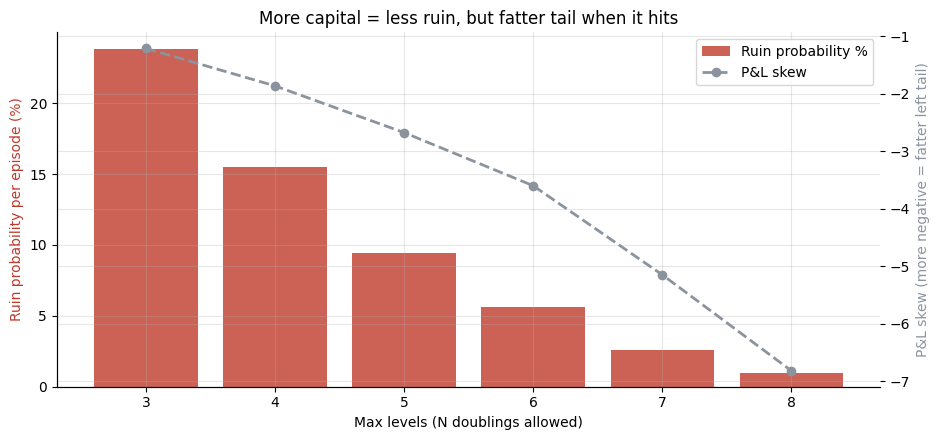

  3 levels (  7x capital): ruin 23.8%, skew -1.214
  4 levels ( 15x capital): ruin 15.5%, skew -1.865
  5 levels ( 31x capital): ruin 9.4%, skew -2.677
  6 levels ( 63x capital): ruin 5.6%, skew -3.600
  7 levels (127x capital): ruin 2.6%, skew -5.148
  8 levels (255x capital): ruin 1.0%, skew -6.816


In [4]:
levels = [3, 4, 5, 6, 7, 8]
cap_units = [2**l - 1 for l in levels]
ruin_pcts = [23.8, 15.5, 9.4,
             5.6, 2.6, 1.0]
skews = [-1.214, -1.865, -2.677,
         -3.6, -5.148, -6.816]

fig, ax1 = plt.subplots(figsize=(9.5, 4.5))
ax1.bar(levels, ruin_pcts, color=RED, alpha=0.8, label='Ruin probability %')
ax1.set_xlabel('Max levels (N doublings allowed)')
ax1.set_ylabel('Ruin probability per episode (%)', color=RED)
ax2 = ax1.twinx()
ax2.plot(levels, skews, 'o--', c=GREY, lw=2, label='P&L skew')
ax2.set_ylabel('P&L skew (more negative = fatter left tail)', color=GREY)
ax1.set_title('More capital = less ruin, but fatter tail when it hits')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout(); plt.show()

for l, c, r, s in zip(levels, cap_units, ruin_pcts, skews):
    print(f'  {l} levels ({c:3d}x capital): ruin {r:.1f}%, skew {s:+.3f}')

Adding more capital levels lowers the per-episode ruin probability, but the required capital grows exponentially (63x for 6 levels, 255x for 8 levels) while the skew just gets worse — the rare ruin event becomes even more catastrophic relative to the normal wins. There is no free lunch: you cannot buy safety by deploying more capital, you can only move the ruin further out while making it proportionally more destructive.

## 7 · Going further

- **The sister study.** [Study 72 — Loaded-Dice](../../72-loaded-dice/) is the direct sibling: a strategy that manufactures a 90%+ win-rate via exit asymmetry rather than doubling, but exposes the same negative-skew illusion.
- **Does mean-reversion help?** If the market genuinely mean-reverts at the 5% level, averaging down could pay. The quants notebook tests this with a synthetic positive control — the engine finds an edge when you plant mean-reversion, confirming the real market is simply not mean-reverting enough at this scale.
- **The gambler's ruin.** The underlying mathematics — a random walk with absorbing barriers and finite capital — guarantees ruin with probability 1 given enough time. The question is only how long it takes and what it costs.

*Think there's a smarter entry or exit rule that recovers the edge? Fork this, change the parameters, and show a genuine excess return over B&H with a controlled tail. That's the bar.*